## Введение

### Подготовка корпуса для обучения Word2Vec

В этом ноутбуке будет подготовлен текстовый корпус для обучения моделей Word2Vec на русском языке. В качестве источника данных используется официальный дамп русскоязычной Википедии.

Работа включает полный цикл подготовки данных: загрузку и исследование XML-дампа, извлечение и очистку текста статей, построение текстового корпуса, токенизацию, создание частотного словаря и анализ полученных данных. Подготовленный корпус и словарь будут использованы в следующем ноутбуке для обучения моделей CBOW и Skip-gram.

#### План работы

1. Загрузка дампа русскоязычной Википедии.
2. Исследование структуры XML-дампа.
3. Построение текстового корпуса.
4. Исследование полученного корпуса.
5. Токенизация текста.
6. Построение частотного словаря.
7. Анализ частотного словаря.

## Загрузка дампа Википедии

Для обучения модели используется официальный дамп русскоязычной Википедии, распространяемый Wikimedia Foundation. Дампы публикуются регулярно и содержат статьи в формате XML, сжатые алгоритмом BZip2 (`.bz2`). Они предназначены для исследований, анализа данных и обучения моделей обработки естественного языка.

Актуальные версии дампов доступны на странице: [dumps.wikimedia.org](https://dumps.wikimedia.org/ruwiki/latest/)

В рамках проекта используется файл от 07.2006:

```text
ruwiki-latest-pages-articles.xml.bz2
```

Он содержит тексты всех статей русскоязычной Википедии без истории изменений страниц, что делает его наиболее подходящим для построения текстового корпуса.

После загрузки файл необходимо поместить в каталог проекта:

```text
data/
└── raw/
    └── ruwiki-latest-pages-articles.xml.bz2
```

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Путь к архиву с дампом Википедии
dump_path = Path("../data/raw/ruwiki-latest-pages-articles.xml.bz2")

# Проверяем, что файл существует
if dump_path.exists():
    print("Файл найден")
else:
    print("Файл не найден")

Файл найден


In [2]:
size_gb = dump_path.stat().st_size / 1024**3
print(f"Размер дампа: {size_gb:.2f} ГБ")

Размер дампа: 5.53 ГБ


## Исследование структуры XML

In [3]:
import bz2
import xml.etree.ElementTree as ET

In [4]:
with bz2.open(dump_path, "rt", encoding="utf-8") as f:
    for _ in range(1000):
        print(f.readline(), end="")

<mediawiki xmlns="http://www.mediawiki.org/xml/export-0.11/" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.mediawiki.org/xml/export-0.11/ http://www.mediawiki.org/xml/export-0.11.xsd" version="0.11" xml:lang="ru">
  <siteinfo>
    <sitename>Википедия</sitename>
    <dbname>ruwiki</dbname>
    <base>https://ru.wikipedia.org/wiki/%D0%97%D0%B0%D0%B3%D0%BB%D0%B0%D0%B2%D0%BD%D0%B0%D1%8F_%D1%81%D1%82%D1%80%D0%B0%D0%BD%D0%B8%D1%86%D0%B0</base>
    <generator>MediaWiki 1.46.0-wmf.26</generator>
    <case>first-letter</case>
    <namespaces>
      <namespace key="-2" case="first-letter">Медиа</namespace>
      <namespace key="-1" case="first-letter">Служебная</namespace>
      <namespace key="0" case="first-letter" />
      <namespace key="1" case="first-letter">Обсуждение</namespace>
      <namespace key="2" case="first-letter">Участник</namespace>
      <namespace key="3" case="first-letter">Обсуждение участника</namespace>
      <namespace key="4" case=

In [5]:
with bz2.open(dump_path, "rb") as file:

    for event, element in ET.iterparse(file, events=("end",)):

        if element.tag.endswith("page"):

            print("Первая статья найдена")

            break

Первая статья найдена


## Построение текстового корпуса

In [13]:
from src.parser import WikipediaParser
from src.parser import WikipediaParser
from src.cleaner import WikiCleaner
from src.builder import CorpusBuilder

In [14]:
parser = WikipediaParser(
    dump_path
)

for article in parser.articles():
    print(article.title)
    print(article.text[:500])
    break

Литва
{{другие значения}}{{Перенаправление|Литовская Республика|Литовская Республика (1918—1940)|о периоде существования Литовской республики с 1918 по 1940 год}}{{Государство
| Русское название = Литовская Республика
| Оригинальное название = {{lang-lt|Lietuvos Respublika}}
| Флаг = Flag of Lithuania.svg
| Родительный падеж = Литвы
| Герб = Coat of Arms of Lithuania.svg
| Название гимна = {{lang-lt2|Tautiška giesmė}}
| Перевод названия гимна = Национальная песнь
| Аудио = Tautiška_giesme_instumental.


In [15]:
parser = WikipediaParser(
   dump_path
)

cleaner = WikiCleaner()

article = next(parser.articles())

print(article.title)

print("-" * 80)

print(cleaner.clean(article.text)[:3000])

Литва
--------------------------------------------------------------------------------
Литва́ ( ), официальное название — Лито́вская Респу́блика () — государство, расположенное в Северной Европе. Площадь —  км². Протяжённость с севера на юг — 280 км, а с запада на восток — 370 км. Население составляет  человек (октябрь, 2024). По территории и населению является самым большим балтийским государством. Занимает 143-е место в мире по численности населения и 121-е по территории.

Страна имеет выход к Балтийскому морю и расположена на его восточном побережье. Её береговая линия составляет всего 99 км (наименьший показатель среди государств Балтии). На севере граничит с Латвией, на юго-востоке — с Беларусью, на юго-западе — с Польшей и Калининградской областью России.

Столица и крупнейший город — Вильнюс, другие крупные города — Каунас, Клайпеда, Шяуляй и др. Денежная единица — евро. Официальный язык — литовский.

Становление государственности на территории Литвы произошло в XIII веке, с обр

In [16]:
corpus_path = Path("../data/processed/corpus.txt")

In [17]:
parser = WikipediaParser(dump_path)
cleaner = WikiCleaner()

builder = CorpusBuilder(
    parser=parser,
    cleaner=cleaner,
)

In [18]:
# builder.build(
#     output_path=corpus_path,
# )

## Исследование полученного корпуса

In [19]:
import pandas as pd

In [20]:
corpus_path = Path("../data/processed/corpus_wiki_ru_07_26.txt")

In [21]:
with corpus_path.open(encoding="utf-8") as f:
    print(f.read(3000))

Литва́ ( ), официальное название — Лито́вская Респу́блика () — государство, расположенное в Северной Европе. Площадь —  км². Протяжённость с севера на юг — 280 км, а с запада на восток — 370 км. Население составляет  человек (октябрь, 2024). По территории и населению является самым большим балтийским государством. Занимает 143-е место в мире по численности населения и 121-е по территории.

Страна имеет выход к Балтийскому морю и расположена на его восточном побережье. Её береговая линия составляет всего 99 км (наименьший показатель среди государств Балтии). На севере граничит с Латвией, на юго-востоке — с Беларусью, на юго-западе — с Польшей и Калининградской областью России.

Столица и крупнейший город — Вильнюс, другие крупные города — Каунас, Клайпеда, Шяуляй и др. Денежная единица — евро. Официальный язык — литовский.

Становление государственности на территории Литвы произошло в XIII веке, с образованием Великого княжества Литовского. В XVI веке Литва объединилась с Польшей, образ

In [ ]:
size_gb = corpus_path.stat().st_size / 1024**3 #размер корпуса
print(f"Размер корпуса: {size_gb:.2f} GB")

Размер корпуса: 14.58 GB


In [23]:
with corpus_path.open(encoding="utf-8") as f: #кол-во строк
    lines = sum(1 for _ in f)

print(f"Строк: {lines:,}")

Строк: 105,506,834


In [24]:
characters = corpus_path.stat().st_size #кол-во символов

print(f"Символов (примерно): {characters:,}")

Символов (примерно): 15,652,730,050


In [25]:
print(f"Средняя длина строки: {characters / lines:.1f}") #ср. длина строки

Средняя длина строки: 148.4


## Токенизация и построение частотного словаря

In [29]:
from src.tokenizer import Tokenizer
from src.dictionary import FrequencyDictionary


In [32]:
# tokenizer = Tokenizer()
dictionary = FrequencyDictionary()

# with corpus_path.open(encoding="utf-8") as file:
#     dictionary.fit(
#         tokenizer.tokenize_stream(file)
#     )


dictionary.load(
    Path("../data/processed/frequency_dictionary.json")
)

In [34]:
print(f"Количество слов: {dictionary.vocabulary_size:,}")
print(f"Количество токенов: {dictionary.total_words:,}")

Количество слов: 11,955,556
Количество токенов: 1,136,266,743


## Исследование словаря

In [38]:
import matplotlib.pyplot as plt

In [36]:
dictionary.most_common(20)

[('в', 48443498),
 ('и', 28974349),
 ('на', 15539436),
 ('с', 13013721),
 ('по', 8147025),
 ('не', 7620652),
 ('года', 7481974),
 ('категория', 7313960),
 ('а', 5392378),
 ('что', 5266852),
 ('из', 5236460),
 ('utc', 5202511),
 ('году', 5052569),
 ('к', 4553442),
 ('как', 3755520),
 ('за', 3721763),
 ('для', 3645264),
 ('от', 3556746),
 ('был', 3328944),
 ('о', 3126902)]

In [37]:
rare_words = [
    word
    for word, count in dictionary.word_counts.items()
    if count == 1
]

print(len(rare_words))
print(rare_words[:100])

6774865
['аукштасис', 'беларусимядзведзеў', 'латышскогоэйдинтас', 'вклэйдинтас', 'месяцnuo', 'taislius', 'auguminis', 'клиоре', 'авиженис', 'konversija', 'jūrinis', 'kibernetinės', 'doktrinų', 'komendantūrų', 'operatyvinių', 'tarnybų', 'pakrančių', 'viešojo', 'державароссия', 'потенциалаpodvig', 'миракошкин', 'lestvitsa', 'рωсїѧ', 'кыевскым', 'царствохорошкевич', 'россииназваниедлина', 'россииназваниеплощадь', 'оглеённые', 'полярнопустынная', 'арктотундра', 'гектаровшапарев', 'республикадругие', 'государствацукерман', 'царьиван', 'орёлсоболева', 'смоленскаа', 'приказыпетров', 'постамвахрушева', 'ruпроф', 'силмягков', 'нацизмомсогласно', 'еэсплан', 'натоцентрально', 'снгсоглашение', 'государствамихолодная', 'другиебарсенков', 'операциикрамник', 'рфаннексированные', 'военнослужащихпутин', 'немонопольных', 'золотамеждународные', 'eжемесячные', 'россиипромышленное', 'активовпоказатели', 'гражданобъем', 'новостройкахгде', 'поликлиниксчетная', 'сырьяджим', 'жителейструктура', 'капиталавакуле

In [39]:
frequencies = [
    count
    for _, count in dictionary.most_common(dictionary.vocabulary_size)
]

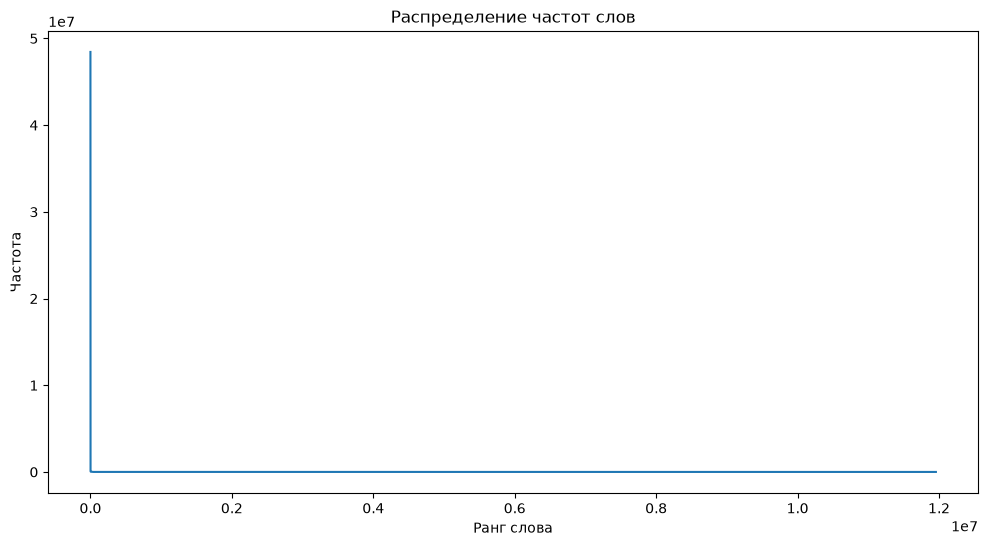

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(frequencies)

plt.title("Распределение частот слов")
plt.xlabel("Ранг слова")
plt.ylabel("Частота")

plt.show()

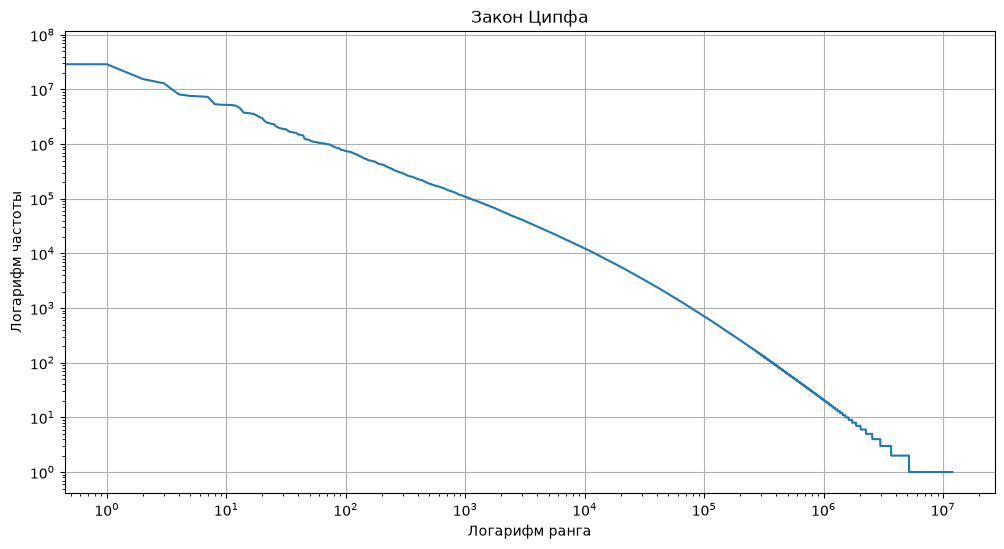

In [41]:
plt.figure(figsize=(12, 6))

plt.loglog(frequencies)

plt.title("Закон Ципфа")
plt.xlabel("Логарифм ранга")
plt.ylabel("Логарифм частоты")

plt.grid(True)

plt.show()

In [42]:
def vocabulary_size(
    dictionary,
    min_count,
):
    return sum(
        1
        for frequency in dictionary.word_counts.values()
        if frequency >= min_count
    )

In [43]:
for min_count in [
    1,
    2,
    5,
    10,
    20,
    50,
    100,
    500,
    1000,
]:
    print(
        f"{min_count:>5}: "
        f"{vocabulary_size(dictionary, min_count):,}"
    )

    1: 11,955,556
    2: 5,180,691
    5: 2,550,175
   10: 1,617,504
   20: 1,042,179
   50: 582,004
  100: 373,366
  500: 127,736
 1000: 78,051
